# Heart Disease Prediction using Logistic Regression

#### Project Overview

Heart disease is one of the leading causes of death worldwide making early detection an important healthcare objective. In this project, a logistic regression model is developed to predict whether a patient has heart disease based on demographic and clinical information such as age, blood pressure, cholesterol levels, ECG results and exercise-related measurements.

This notebook demonstrates an end-to-end binary classification workflow, including data loading, preprocessing, model training, and performance evaluation. A Logistic Regression model is used to classify patients as either having heart disease (Presence) or not having heart disease (Absence). The model's performance is assessed using Accuracy, Precision, Recall, and F1 Score to evaluate its effectiveness.

This notebook covers:

1. Data Loading
2. Exploratory Data Analysis
3. Data Preprocessing
4. Model Training
5. Model Evaluation
6. Interpretation of Results

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

### Dataset Loading

The training dataset contains patient health records along with the heart disease label.

Each row represents one patient observation.

In [ ]:
df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (630000, 15)


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


We have 630000 records and 13 columns.

### Data Analysis

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

In [ ]:
df.describe()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,54.136706,0.714735,3.312752,130.497433,245.011814,0.079987,0.981660,152.816763,0.273725,0.716028,1.455871,0.451040,4.618873
std,181865.479132,8.256301,0.451541,0.851615,14.975802,33.681581,0.271274,0.998783,19.112927,0.445870,0.948472,0.545192,0.798549,1.950007
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000
25%,157499.750000,48.000000,0.000000,3.000000,120.000000,223.000000,0.000000,0.000000,142.000000,0.000000,0.000000,1.000000,0.000000,3.000000
50%,314999.500000,54.000000,1.000000,4.000000,130.000000,243.000000,0.000000,0.000000,157.000000,0.000000,0.100000,1.000000,0.000000,3.000000
75%,472499.250000,60.000000,1.000000,4.000000,140.000000,269.000000,0.000000,2.000000,166.000000,1.000000,1.400000,2.000000,1.000000,7.000000
max,629999.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000


In [ ]:
df.isnull().sum()

id                         0
Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

There are no missing values in the dataset.

In [ ]:
df.duplicated().sum()

np.int64(0)

There are no duplicates in the dataset.

### Target Variable Distribution

Understanding class distribution helps determine whether the dataset is balanced or imbalanced.

In [ ]:
df["Heart Disease"].value_counts()

Heart Disease
Absence     347546
Presence    282454
Name: count, dtype: int64

The dataset is relatively balanced with 55.2% negative cases and 44.8% positive cases. No additional class-balancing techniques were required before model training.

### Data Preprocessing

The target variable is converted into numerical format:

- Absence → 0
- Presence → 1

In [ ]:
df["Heart Disease"] = df["Heart Disease"].map({
    "Absence":0,
    "Presence":1
})

In [ ]:
X = df.drop(
    columns=["Heart Disease","id"]
)

y = df["Heart Disease"]

### Train-Test Split

The dataset is split into:

- 80% Training Data
- 20% Testing Data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Stratified sampling was used during the train-test split to preserve the original class distribution of the target variable in both the training and testing datasets. This helps ensure that model evaluation is performed on a representative sample of the data.

In [ ]:
print(X_train.shape)
print(X_test.shape)

(504000, 13)
(126000, 13)


### Feature Scaling

Logistic Regression performs better when features are on a similar scale.

StandardScaler transforms each feature to:

- Mean = 0
- Standard Deviation = 1

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Model Selection

Logistic Regression is chosen because:

- It is simple and interpretable
- Works well for binary classification
- Serves as a strong baseline model

In [ ]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Model Prediction

Generate predictions on unseen test data.

In [ ]:
y_pred = model.predict(X_test_scaled)

### Model Evaluation

#### Detailed Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.89      0.91      0.90     69509
           1       0.88      0.86      0.87     56491

    accuracy                           0.88    126000
   macro avg       0.88      0.88      0.88    126000
weighted avg       0.88      0.88      0.88    126000



#### Interpretation

The model performs well for both classes, achieving an overall accuracy of 88%.

For patients without heart disease (Class 0), the model achieved a precision of 89%, recall of 91%, and F1-score of 90%, indicating strong performance in correctly identifying healthy patients.

For patients with heart disease (Class 1), the model achieved a precision of 88%, recall of 86%, and F1-score of 87%. This shows that the model is effective at detecting heart disease, although a small number of positive cases are still missed.

The macro and weighted averages are both 88%, suggesting balanced performance across both classes without significant bias. Overall, the model demonstrates strong and consistent classification performance on the test dataset.

### Confusion Matrix

The confusion matrix provides a detailed breakdown of prediction outcomes.

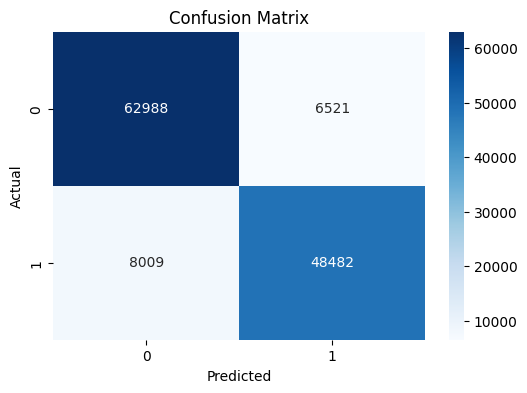

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

#### Confusion Matrix Interpretation

The confusion matrix shows that the model correctly classified 62,988 patients without heart disease (True Negatives) and 48,482 patients with heart disease (True Positives).

However, 6,521 healthy patients were incorrectly predicted as having heart disease (False Positives), while 8,009 patients with heart disease were incorrectly classified as healthy (False Negatives).

Overall, the number of correct predictions is significantly higher than the number of misclassifications, indicating strong model performance. The false negatives are slightly higher than the false positives, suggesting that some heart disease cases are missed, which may be an area for improvement in future model iterations.

### Final Summary

In this project, a Logistic Regression model was developed to predict the presence of heart disease using patient demographic and clinical information. The dataset was preprocessed by encoding the target variable, removing non-predictive fields, and applying feature scaling. The data was then divided into training and testing sets using stratified sampling to maintain the original class distribution.

The model achieved an accuracy of 88.47%, precision of 88.14%, recall of 85.82%, and an F1-score of 86.97%, indicating strong overall performance. The classification report and confusion matrix showed that the model was able to correctly identify the majority of patients with and without heart disease while maintaining balanced performance across both classes.

Although some heart disease cases were missed, the number of correct predictions was significantly higher than the number of misclassifications. Overall, the results demonstrate that Logistic Regression is an effective baseline model for this binary classification task and provides a solid foundation for future improvements using more advanced machine learning algorithms.